In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import statsmodels.api as sm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [48]:
# Downloading Data
end = dt.date.today()
start = end - dt.timedelta(365)
a = yf.download(["RELIANCE.NS", "^NSEI"], start=start, end=end, auto_adjust=True)['Close']

# Cleaning Data
a.columns = ['reliance', 'nse']

# Returns
returns = a.pct_change().dropna()

x = returns['nse']
y = returns['reliance']

# model
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

[*********************100%***********************]  2 of 2 completed

                            OLS Regression Results                            
Dep. Variable:               reliance   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     201.6
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.02e-33
Time:                        12:55:07   Log-Likelihood:                 796.47
No. Observations:                 245   AIC:                            -1589.
Df Residuals:                     243   BIC:                            -1582.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.886      0.3

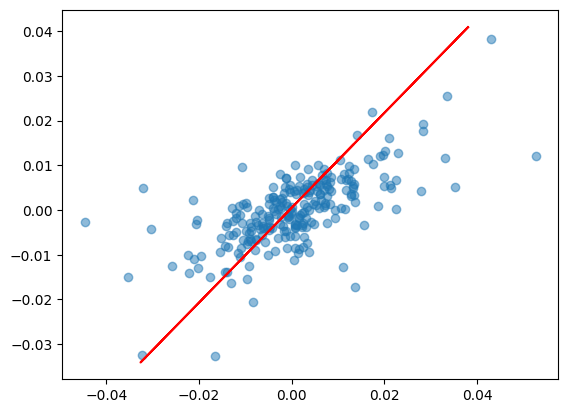

In [49]:
plt.scatter(returns['reliance'], returns['nse'],alpha=0.5,label = 'Daily Returns')
plt.plot(returns['nse'],model.fittedvalues,color='red',label = 'Regression Line')

In [50]:
print(f"R-Squared: {model.rsquared:.4f}")
print(f"Adj. R-Squared: {model.rsquared_adj:.4f}")
print(f"Alpha (Intercept): {model.params.iloc[0]:.4f}")
print(f"Beta (Reliance): {model.params.iloc[1]:.4f}")

# Error Metrics
print(f"MSE: {model.mse_resid:.4f}")
print(f"RMSE: {np.sqrt(model.mse_resid):.4f}")
print(f"MAE: {np.mean(np.abs(model.resid)):.4f}")

R-Squared: 0.4534
Adj. R-Squared: 0.4511
Alpha (Intercept): 0.0005
Beta (Reliance): 1.0616
MSE: 0.0001
RMSE: 0.0094
MAE: 0.0067
